### Foreground comparison

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.io.fits as fits
from scipy.interpolate import InterpolatedUnivariateSpline
from scipy.signal import savgol_filter
import os


In [32]:
def extrapolate(ell, dell, lmax, order=1,lmin=0, lower=0):
    s = InterpolatedUnivariateSpline(ell, dell, k=order)
    if lmin ==0 :
        x = np.arange(np.max(ell)+1, lmax, 1)
    else:
        x = np.arange(lmin, lmax, 1)
            
    y = s(x)
    #print(ell[-1],x)

    if lmin ==0 :
        elln = np.hstack((ell, x))
        delln = np.hstack((dell,y))
    else:
        if lmin < ell[0]:
            elln = x
            delln = y
            
        else:
                    
            elln = np.hstack((ell[0:lmin+1], x))
            delln = np.hstack((dell[0:lmin+1],y))

    print(elln)
    
    #lower 
    s = InterpolatedUnivariateSpline(elln, delln, k=order)
    if lower !=0 :
        x = np.arange(2, lower, 1)
            
        y = s(x)
    
                    
        elln = np.hstack((x,elln[lower:]))
        delln = np.hstack((y,delln[lower:]))

        print(elln)
  

    return (elln,delln)

#### tSZ

In [3]:
tr = np.genfromtxt("../data/dl_shaw_tsz_s10_153ghz_norm1_fake25000.txt")
shaw_ell, shaw_dell = tr[:,0], tr[:,1]

In [4]:
filename = "dl_tsz_150_bat.dat"
root = "../data/"
tr = np.genfromtxt(root+filename)

batt_ellt, batt_dellt = tr[:,0], tr[:,1]


ll, dd=extrapolate(batt_ellt,batt_dellt,13501)


batt_ell, batt_dell = ll,dd
newfilename = os.path.join(root + filename.replace(".dat", "_13500.dat"))

print(newfilename)

np.savetxt(newfilename,np.column_stack([batt_ell,batt_dell/batt_dell[3000]]) )


[2.0000e+00 3.0000e+00 4.0000e+00 ... 1.3498e+04 1.3499e+04 1.3500e+04]
../data/dl_tsz_150_bat_13500.dat


(900, 13500)

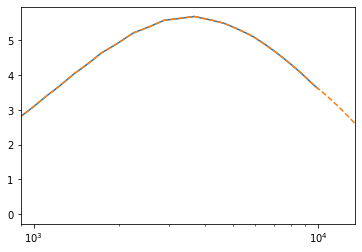

In [5]:
plt.figure()
plt.semilogx(batt_ellt, batt_dellt)
plt.semilogx(ll, dd, "--")

plt.xlim(900,13500)


[2.0000e+00 3.0000e+00 4.0000e+00 ... 1.3498e+04 1.3499e+04 1.3500e+04]


(0.0, 13500.0)

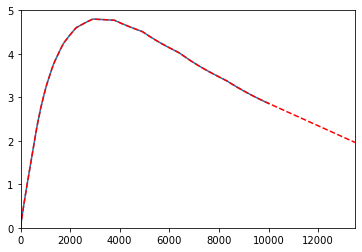

In [6]:

filename = "tsz_143_eps0.50.dat"
tr = np.genfromtxt(root+filename)
cam_ellt, cam_dellt = tr[:,0], tr[:,1]
cam_dellt = savgol_filter(cam_dellt, 151, 3) # window size 51, polynomial order 3


if np.max(cam_ellt) < 13500:
    cam_ell, cam_dell = extrapolate(cam_ellt, cam_dellt,13501, order=1)

newfilename = os.path.join(root + filename.replace(".dat", "_13500.dat"))

np.savetxt(newfilename,np.column_stack([cam_ell,cam_dell/cam_dell[3000]]) )

plt.figure()
plt.plot(cam_ellt, cam_dellt)
plt.plot(cam_ell, cam_dell, "r--")
plt.ylim(0,5)
plt.xlim(0,13500)



In [7]:
filename = "ClSZ_poiss_corr_MD2_cppp_bestCl_NILC_extra12_cibps_lmax10000.res"
tr = np.genfromtxt(root+filename)
oldmd_ellt, oldmd_dellt = tr[:,0], tr[:,1]

if np.max(oldmd_ellt) < 13500:
    oldmd_ell, oldmd_dell = extrapolate(oldmd_ellt, oldmd_dellt,13501)

newfilename = os.path.join(root + filename.replace(".res", "_13500.dat"))

np.savetxt(newfilename,np.column_stack([oldmd_ell,oldmd_dell/oldmd_dell[3000]]) )


[2.0000e+00 3.0000e+00 4.0000e+00 ... 1.3498e+04 1.3499e+04 1.3500e+04]


In [8]:
tr = fits.getdata("../data/tkSZ_Dl_SZDB.fits")
md_ell, md_dell = tr["ell"], tr["tSZ_Dl_mod_95x150_muK2"]
ag_ell, ag_dell = tr["ell"], tr["kSZ_Dl_mod_muK2"]


ag_ell2 = np.hstack(([0,1],ag_ell))
ag_dell2 = np.hstack(([0,0],ag_dell))

ag_dell2=ag_dell2/ag_dell2[3000]
    
print(ag_dell2)

#np.savetxt("../data/dl_ksz_AGRF.dat", np.column_stack([ag_ell2, ag_dell2]))

md_ell2 = np.hstack(([0,1],md_ell))
md_dell2 = np.hstack(([0,0],md_dell))

md_dell2=md_dell2/md_dell2[3000]
    
print(md_dell2.shape)

#np.savetxt("../data/dl_tsz_MDRF.dat", np.column_stack([md_ell2, md_dell2]))


#np.savetxt("../data/dl_tsz_MDRFsameAbhi.dat", np.column_stack([md_ell2, md_dell2]))

direc="../data/"
tr = np.genfromtxt(direc+"dl_tSZ_1h2h_Abi_143.dat")
abi_ell, abi_dell = tr[:,0], tr[:,1]

[0.00000000e+00 0.00000000e+00 5.18221879e-07 ... 1.50985355e+00
 1.50986849e+00 1.50988333e+00]
(13501,)


#### plotting

(10.0, 13500.0)

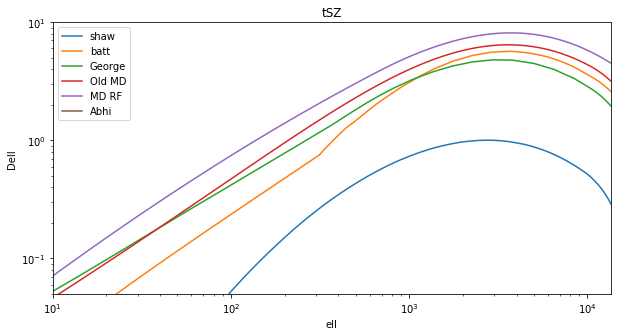

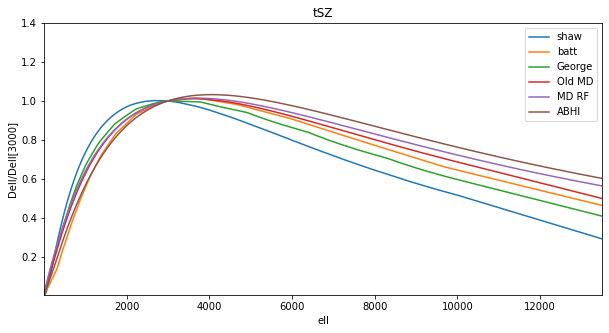

In [9]:
plt.figure(figsize=(10,5))
plt.loglog()
plt.title("tSZ")
plt.plot(shaw_ell, shaw_dell, label="shaw")
plt.plot(batt_ell, batt_dell, label="batt")
plt.plot(cam_ell, cam_dell, label="George")
plt.plot(oldmd_ell, oldmd_dell, label="Old MD")
plt.plot(md_ell, md_dell, label="MD RF")
plt.plot(abi_ell, abi_dell, label="Abhi")
plt.legend()
plt.xlabel("ell")
plt.ylabel("Dell")
plt.ylim(5e-2,1e1)
plt.xlim(10,1.35e4)


plt.figure(figsize=(10,5))
#plt.loglog()
plt.title("tSZ")
plt.plot(shaw_ell, shaw_dell/shaw_dell[3000], label="shaw")
plt.plot(batt_ell, batt_dell/batt_dell[3000], label="batt")
plt.plot(cam_ell, cam_dell/cam_dell[3000], label="George")
plt.plot(oldmd_ell, oldmd_dell/oldmd_dell[3000], label="Old MD")
plt.plot(md_ell2, md_dell2,  label="MD RF")
plt.plot(abi_ell, abi_dell/abi_dell[2998],  label="ABHI")

plt.legend()
plt.ylim(5e-3,1.4)
plt.xlabel("ell")
plt.ylabel("Dell/Dell[3000]")
plt.xlim(10,1.35e4)



#### kSZ

In [10]:
tr = np.genfromtxt("../data/dl_ksz_CSFplusPATCHY_13sep2011_norm1_fake25000.txt")
csfp_ell, csfp_dell = tr[:,0], tr[:,1]

[2.0000e+00 3.0000e+00 4.0000e+00 ... 1.3498e+04 1.3499e+04 1.3500e+04]
../data/dl_ksz_bat_13500.dat


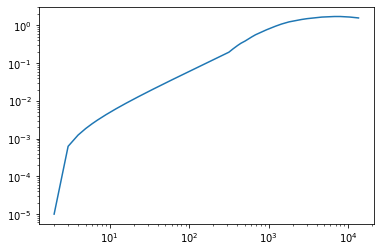

In [11]:

filename = "dl_ksz_bat.dat"
tr = np.genfromtxt(root+filename)

kbat_ellt, kbat_dellt = tr[:,0], tr[:,1]


kbat_ell, kbat_dell =extrapolate(kbat_ellt,kbat_dellt,13501)

newfilename = os.path.join(root + filename.replace(".dat", "_13500.dat"))

print(newfilename)

np.savetxt(newfilename,np.column_stack([kbat_ell,kbat_dell/kbat_dell[3000]]) )

#np.savetxt("../data/dl_ksz_150_bat_norm3000.dat",np.column_stack([kbat_ell,kbat_dell/kbat_dell[3000]]) )

plt.loglog(kbat_ell, kbat_dell)

In [12]:
tr = np.genfromtxt("../data/dl_ksz_oz_patchy_nolowell_20110708_norm1_fake25000.txt")
oz_ell, oz_dell = tr[:,0], tr[:,1]

In [13]:
tr = np.genfromtxt("../data/cl_tksz_148_tbo1.dat")
tbo_ell, tbo_dell = tr[:,0], tr[:,1]



In [54]:
tr = np.genfromtxt("../data/ksz_Iliev_patchy_13_div2726.csv", delimiter=",")
ili_ell, ili_dell = tr[:,0], tr[:,1]
tr = np.genfromtxt("../data/ksz_Mmcquin_patchy_10_div2726.csv", delimiter=",")
mac_ell, mac_dell = tr[:,0], tr[:,1]
tr = np.genfromtxt("../data/ksz_Alvarez_patchy_10_05.csv", delimiter=",")
alv_ell, alv_dell = tr[:,0], tr[:,1]

tr = np.genfromtxt("../data/lcls_plot_ksz.dat")
plck_ell, plck_dell = tr[100:,2], tr[100:,3]

tr= np.genfromtxt("../data/cl_ksz_planck.dat")
reiop_ellt, reiop_dellt = tr[87:,0], tr[87:,1]


reiop_ell, reiop_dell =extrapolate(reiop_ellt,reiop_dellt,13501, lower=87, order=1)



[   89.    90.    91. ... 13498. 13499. 13500.]
[2.0000e+00 3.0000e+00 4.0000e+00 ... 1.3498e+04 1.3499e+04 1.3500e+04]


##### plotting

(10, 13500.0)

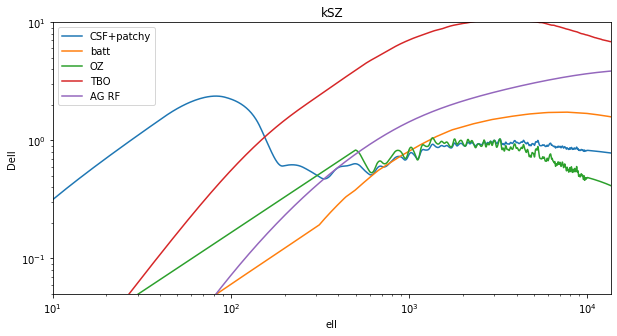

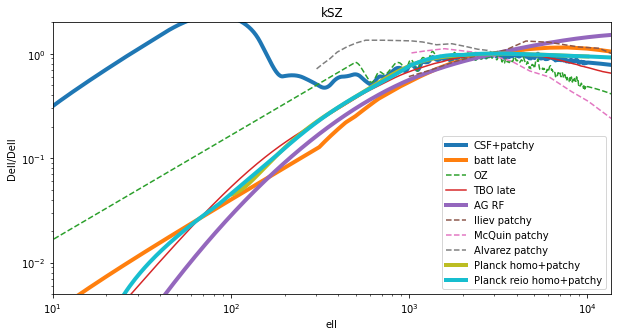

In [55]:
plt.figure(figsize=(10,5))
plt.loglog()
plt.title("kSZ")
plt.plot(csfp_ell, csfp_dell, label="CSF+patchy")
plt.plot(kbat_ell, kbat_dell, label="batt")
plt.plot(oz_ell, oz_dell, label="OZ")
plt.plot(tbo_ell, tbo_dell, label="TBO")
plt.plot(ag_ell, ag_dell, label="AG RF")
plt.legend()
plt.xlabel("ell")
plt.ylabel("Dell")
plt.ylim(5e-2,1e1)
plt.xlim(10,1.35e4)

plt.figure(figsize=(10,5))
plt.loglog()
plt.title("kSZ")
plt.plot(csfp_ell, csfp_dell/csfp_dell[3000], lw=4,label="CSF+patchy")
plt.plot(kbat_ell, kbat_dell/kbat_dell[3000], lw=4,label="batt late")
plt.plot(oz_ell, oz_dell/oz_dell[3000], "--",label="OZ")
plt.plot(tbo_ell, tbo_dell/tbo_dell[3000], label="TBO late")
plt.plot(ag_ell, ag_dell/ag_dell[3000], lw=4,label="AG RF")

plt.plot(ili_ell,ili_dell/ili_dell[3],"--", label="Iliev patchy")
plt.plot(mac_ell,mac_dell/mac_dell[3], "--",label="McQuin patchy")
plt.plot(alv_ell,alv_dell/alv_dell[16],"--", label="Alvarez patchy")

plt.plot(plck_ell,plck_dell/plck_dell[2900], lw=4,label="Planck homo+patchy")
plt.plot(reiop_ell,reiop_dell/reiop_dell[2900], lw=4,label="Planck reio homo+patchy")




plt.legend()
plt.xlabel("ell")
plt.ylabel("Dell/Dell")
plt.ylim(5e-3,2)
plt.xlim(10,1.35e4)


### CIB

In [29]:
print(root)

../data/


13500
[2.0000e+00 3.0000e+00 4.0000e+00 ... 1.3498e+04 1.3499e+04 1.3500e+04]
../data/cib_extra_13500.dat
[  100   101   102 ... 13498 13499 13500]
../data/dl_CIB_1h_2h_Abi_545_13500.dat
[    0     1     2 ... 13498 13499 13500]
../data/CLs_CIBCIB_fmccarthy_github_545_13500.dat
[2.0000e+00 3.0000e+00 4.0000e+00 ... 1.3498e+04 1.3499e+04 1.3500e+04]
../data/cl_cib_cib_545_websky_l_cl_090322_13500.dat


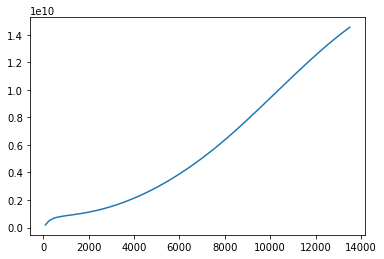

In [17]:
lmax = int(np.max(md_ell2))

print(lmax)

tr = np.genfromtxt("../data/dl_cib_1halo_norm1_25000.txt")
cib1_ell, cib1_dell = tr[:,0], tr[:,1]
tr = np.genfromtxt("../data/dl_cib_2halo_norm1_25000.txt")
cib2_ell, cib2_dell = tr[:,0], tr[:,1]

tr = cib2_dell
cib_dell = np.zeros(lmax+1)
cib_dell[np.array(cib2_ell[cib2_ell<=lmax],int)] = tr[cib2_ell<=lmax]
tr = cib2_dell+cib1_dell
cibs_dell = np.zeros(lmax+1)
cibs_dell[np.array(cib2_ell[cib2_ell<=lmax],int)] = tr[cib2_ell<=lmax]

filename = "cib_extra.dat"
tr = np.genfromtxt(root+filename)
cibe_ellt, cibe_dellt = tr[:,0], tr[:,1]

cibe_ell, cibe_dell = extrapolate(cibe_ellt,cibe_dellt,13501)
newfilename = os.path.join(root + filename.replace(".dat", "_13500.dat"))
print(newfilename)
np.savetxt(newfilename,np.column_stack([cibe_ell,cibe_dell/cibe_dell[3000]]) )



tr = np.genfromtxt("../data/dl_CIB_1h_Abi_545.dat")
ciba1h_ell, ciba1h_dell = tr[:,0], tr[:,1]
tr = np.genfromtxt("../data/dl_CIB_2h_Abi_545.dat")
ciba2h_ell, ciba2h_dell = tr[:,0], tr[:,1]

ciba_ell, ciba_dell = extrapolate(ciba1h_ell,ciba1h_dell+ciba2h_dell,13501,lmin=100,order=3)
filename = "dl_CIB_1h_2h_Abi_545.dat"

newfilename = os.path.join(root + filename.replace(".dat", "_13500.dat"))
print(newfilename)
np.savetxt(newfilename,np.column_stack([ciba_ell,ciba_dell/ciba_dell[3000]]) )





filename = "CLs_CIBCIB_fmccarthy_github_545.npy"
tr = np.load(root + filename, allow_pickle=True,fix_imports=True)

ellmcct = np.arange(np.shape(tr)[0])

factcc= ellmcct*(ellmcct+1)/2./np.pi

cibmccarthyt = tr*factcc


ellmcc, cibmccarthy  =extrapolate(ellmcct,cibmccarthyt,13501, lmin=9900)
newfilename = os.path.join(root + filename.replace(".npy", "_13500.dat"))
print(newfilename)
np.savetxt(newfilename,np.column_stack([ellmcc,cibmccarthy/cibmccarthy[3000]]) )


filename = "cl_cib_cib_545_websky_l_cl_090322.txt"
tr = np.genfromtxt(root+filename)
websky_ellt, websky_dellt = tr[:,0], tr[:,1]
factw= websky_ellt*(websky_ellt+1)/2./np.pi
websky_dellt=websky_dellt*factw
websky_dellt=websky_dellt/websky_dellt[3000]
websky_ell, websky_dell  = extrapolate(websky_ellt,websky_dellt,13501)
newfilename = os.path.join(root + filename.replace(".txt", "_13500.dat"))
print(newfilename)
np.savetxt(newfilename,np.column_stack([websky_ell, websky_dell/websky_dell[3000]]) )



plt.figure()
plt.plot(ciba_ell, ciba_dell)



[  100   101   102 ... 13498 13499 13500]


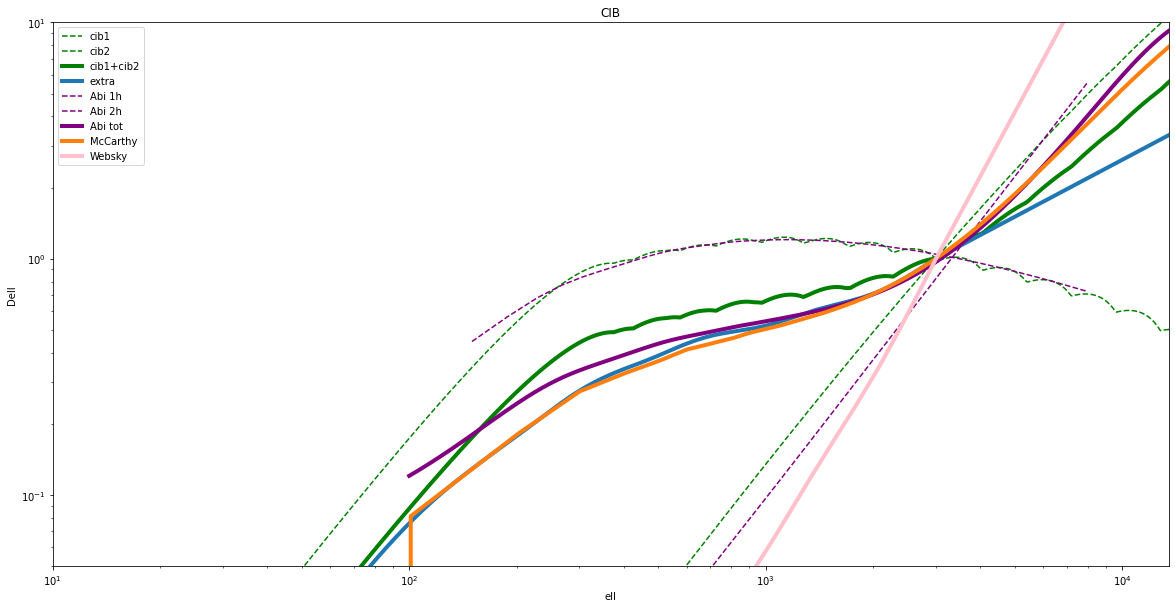

In [18]:
plt.figure(figsize=(20,10))
plt.loglog()
plt.title("CIB")
plt.plot(cib1_ell, cib1_dell, "g--",label="cib1")
plt.plot(cib2_ell, cib2_dell, "g--", label="cib2")
plt.plot(cib1_ell, (cib1_dell+cib2_dell)/(cib1_dell+cib2_dell)[3000], lw=4,color="g",label="cib1+cib2")
plt.plot(cibe_ell, cibe_dell, lw=4, label="extra")

plt.plot(ciba1h_ell, ciba1h_dell/ciba1h_dell[22]/10, "--", color="purple",label="Abi 1h")
plt.plot(ciba2h_ell, ciba2h_dell/ciba2h_dell[22]*1.2, "--", color="purple", label="Abi 2h")
#plt.plot(ciba2h_ell, (ciba2h_dell/ciba2h_dell[22]+ciba1h_dell/ciba1h_dell[22])/(ciba2h_dell/ciba2h_dell[22]+ciba1h_dell/ciba1h_dell[22])[72], lw=4, color="purple",  label="Abi Tot")
plt.plot(ciba_ell, ciba_dell/ciba_dell[3000], lw=4,color="purple", label="Abi tot")
         
plt.plot(ellmcc, cibmccarthy/cibmccarthy[3000], lw=4, label="McCarthy")

plt.plot(websky_ell, websky_dell, lw=4, color="pink", label="Websky")

plt.legend()
plt.xlabel("ell")
plt.ylabel("Dell")
plt.ylim(5e-2,1e1)
plt.xlim(10,1.35e4)

print(ciba_ell)

### SZxCIB

In [19]:
lmax= 13500
filename = "sz_x_cib_template.dat"
tr = np.genfromtxt(root+filename)
xi_ellt, xi_dellt = tr[:,0], tr[:,1]

xi_ell, xi_dell=extrapolate(xi_ellt,xi_dellt,13501)

newfilename = os.path.join(root + filename.replace(".dat", "_13500.dat"))

print(newfilename)

np.savetxt(newfilename,np.column_stack([xi_ell,xi_dell/xi_dell[3000]]) )



xirf_ell = md_ell2
xirf_dell = np.sqrt(md_dell2 * cibs_dell)
xirf2_dell = np.sqrt(md_dell2 * cib_dell)

#ShangModelCorrelationShape) then
l_divide_3000 = np.arange(lmax+1)/3000.
tsz_dgcl_cor = 0.0703 * (l_divide_3000*l_divide_3000) +  0.612 * l_divide_3000 +  0.458

# other
tsz_dgcl_cor2 = 1.0
tsz_cib_slope = 0.1
tsz_dgcl_cor2 = tsz_dgcl_cor2 + (l_divide_3000-1)*tsz_cib_slope



[2.0000e+00 3.0000e+00 4.0000e+00 ... 1.3498e+04 1.3499e+04 1.3500e+04]
../data/sz_x_cib_template_13500.dat


[0.458      0.45820401 0.45840803 ... 4.63474523 4.63516011 4.635575  ]


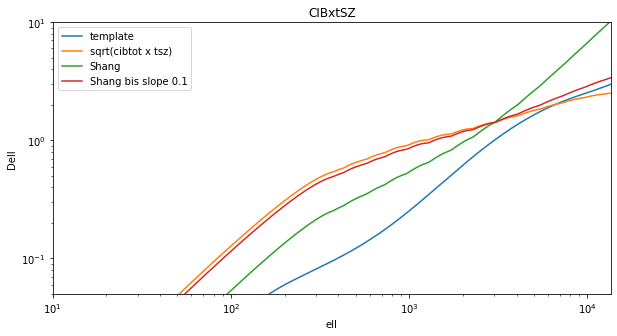

In [20]:
plt.figure(figsize=(10,5))
plt.loglog()
plt.title("CIBxtSZ")
plt.plot(xi_ell, xi_dell, label="template")
plt.plot(xirf_ell, xirf_dell, label="sqrt(cibtot x tsz)")
#plt.plot(xirf_ell, xirf2_dell, label="sqrt(cib2 x tsz)")

plt.plot(l_divide_3000*3000, tsz_dgcl_cor/tsz_dgcl_cor[3000] *xirf_dell , label="Shang")
plt.plot(l_divide_3000*3000, tsz_dgcl_cor2/tsz_dgcl_cor2[3000]*xirf_dell, label="Shang bis slope 0.1")

plt.legend()
plt.xlabel("ell")
plt.ylabel("Dell")
plt.ylim(5e-2,1e1)
plt.xlim(10,1.35e4)
print(tsz_dgcl_cor)

### cirrus


### test cobaya SPT alone



#inputs       

* tsz: dl_shaw_tsz_s10_153ghz_norm1_fake25000_norm3000.txt
* ksz: dl_ksz_CSFplusPATCHY_13sep2011_norm1_fake25000.txt
* cib: cib_extra.dat
* szxcib: sz_x_cib_template.dat
* poisson: null


In [21]:
tr = np.genfromtxt("../data/dl_shaw_tsz_s10_153ghz_norm1_fake25000_norm3000.txt")
shaw_ell, shaw_dell = tr[:,0], tr[:,1]

tr = np.genfromtxt("../data/dl_ksz_CSFplusPATCHY_13sep2011_norm1_fake25000.txt")
csfp_ell, csfp_dell = tr[:,0], tr[:,1]


tr = np.genfromtxt("../data/cib_extra.dat")
cibe_ell, cibe_dell = tr[:,0], tr[:,1]

tr = np.genfromtxt("../data/sz_x_cib_template.dat")
xi_ell, xi_dell = tr[:,0], tr[:,1]

dust_dl= (xi_ell/3000.)**(-1.2)
dust_dl[0:200]=0.

plt.figure(figsize=(10,5))
plt.loglog()
plt.title("SPT alone")
plt.plot(xi_ell, xi_dell, label="xi template")
plt.plot(shaw_ell, shaw_dell, label="shaw")
plt.plot(csfp_ell, csfp_dell, label="CSF+patchy")
plt.plot(cibe_ell, cibe_dell, label="extra")

plt.plot(xi_ell, dust_dl, label="dust")

plt.legend()
plt.xlabel("ell")
plt.ylabel("Dell")
plt.ylim(5e-2,1e1)
plt.xlim(10,1.2e4)
print(tsz_dgcl_cor)

OSError: ../data/dl_shaw_tsz_s10_153ghz_norm1_fake25000_norm3000.txt not found.